In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms, datasets
import matplotlib.pyplot as plt

# Feed-forward Neural Network Model

The neural network model can be described as follows:

$$
\begin{equation}
    \begin{split}
        \boldsymbol{a}^{[0]} &= \boldsymbol{x}\\
        \boldsymbol{a}^{[l+1]} &= \boldsymbol{\sigma}\left(W^{[l+1]}\boldsymbol{a}^{[l]} + \boldsymbol{b}^{[l+1]}\right)\,,\quad \quad l=0:L-1`
    \end{split}
\end{equation}
$$

where $\boldsymbol{x}\in\mathbb{R}^{n_1}$ is a datapoint, $\boldsymbol{b}^{[l+1]}$ is the bias vector at layer $l$, $W^{[l+1]}$ is the matrix of weights that layer $l+1$ applies to the output of layer $l$ and $L$ is the total number of layers.

For any $l=1:L$, $\boldsymbol{\sigma}:\mathbb{R}^{n_l}\rightarrow\mathbb{R}^{n_l}$ is the non-linear activation function applied component-wise.

For any $l=1:L$

$$
\begin{align*}
    &\boldsymbol{z}^{[l+1]} = W^{[l+1]}\boldsymbol{a}^{[l]} + \boldsymbol{b}^{[l+1]}\\
    \implies &\boldsymbol{a}^{[l+1]} = \boldsymbol{\sigma}(\boldsymbol{z}^{[l+1]})
\end{align*}
$$

In [2]:
# Implementing multi-layer perceptron 
class MLP(nn.Module):
    def __init__(self, in_features=10, hidden_features=10, out_features=1, num_layers=50):
        super(MLP, self).__init__()
        
        self.layers = nn.ModuleList()
        
        # Layer 1: Linear
        self.layers.append(nn.Linear(in_features=in_features, out_features=hidden_features))
        
        # Layers 2 to L-1: Linear
        for _ in range(num_layers - 2):
            self.layers.append(nn.Linear(in_features=hidden_features, out_features=hidden_features))
            
        # Layer L: Linear Output
        self.layers.append(nn.Linear(in_features=hidden_features, out_features=out_features))

    def forward(self, x):
        # Flatten the input
        x = x.view(x.size(0), -1)

        x = F.tanh(self.layers[0](x))
        # Layer 1 to L-1: Linear -> Tanh
        for i in range(1,len(self.layers) - 1):
            x = F.tanh(self.layers[i](x))
            
        # Layer L: Output Layer
        x = self.layers[-1](x)
        
        return x

The total loss function $\mathcal{L}$ is function of the actual class labels $y_{i}$ and the network output for all the datapoints $\boldsymbol{a}^{[L]}_i$.

# Backpropagation

To help the network learn, the weights are updated using common gradient-based optimizers such as stochastic gradient descent or Adam. For this, the gradient of the loss function w.r.t. the parameters must be accurately calculated using the backpropagation chain rule.

The gradient of the loss function w.r.t. $\boldsymbol{b}^{[l]}$ can be calculated as follows:
$$
\begin{align*}
    \frac{\partial \mathcal{L}}{\partial \boldsymbol{b}^{[l]}} = \frac{\partial \mathcal{L}}{\partial\boldsymbol{a}^{[L]}} \cdot \frac{\partial\boldsymbol{a}^{[L]}}{\partial \boldsymbol{a}^{[L-1]}}\dots\frac{\partial \boldsymbol{a}^{[l+1]}}{\partial \boldsymbol{a}^{[l]}}\cdot\frac{\partial \boldsymbol{a}^{[l]}}{\partial \boldsymbol{b}^{[l]}}
\end{align*}
$$

Here,

$$
\begin{align*}
    \frac{\partial\boldsymbol{a}^{[l+1]}}{\partial \boldsymbol{a}^{[l]}} = \text{diag}(\sigma'(\boldsymbol{z}^{[l+1]})) W^{[l+1]}
\end{align*}
$$

# Vanishing Gradient Problem

To find the gradient of the loss function with respect to the parameters in an earlier layer, we can observe that the per-layer transition Jacobians are continuously multiplied across the **depth** of the network. The gradient reaching layer $l$ is therefore a product of $L-l$ such Jacobians.

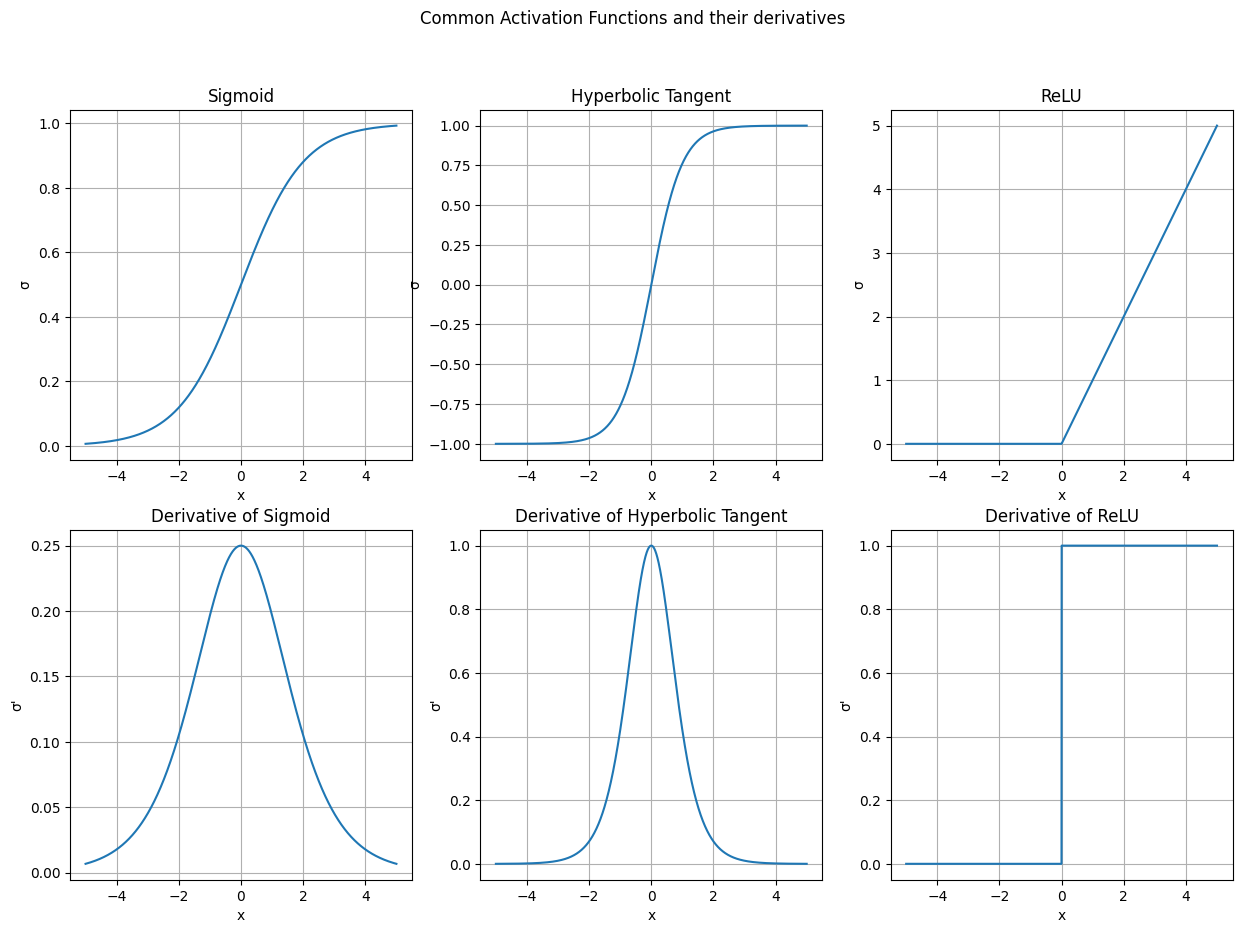

In [3]:
fig, ax = plt.subplots(nrows=2,ncols=3,figsize=(15,10))
grid = torch.linspace(-5,5,2000)

ax[0,0].plot(grid.numpy(),nn.Sigmoid()(grid))
ax[0,0].set_title("Sigmoid")
ax[0,0].grid(True)
ax[0,0].set_xlabel("x")
ax[0,0].set_ylabel("σ")

ax[0,1].plot(grid.numpy(),nn.Tanh()(grid))
ax[0,1].set_title("Hyperbolic Tangent")
ax[0,1].grid(True)
ax[0,1].set_xlabel("x")
ax[0,1].set_ylabel("σ")

ax[0,2].plot(grid.numpy(),nn.ReLU()(grid))
ax[0,2].set_title("ReLU")
ax[0,2].grid(True)
ax[0,2].set_xlabel("x")
ax[0,2].set_ylabel("σ")

ax[1,0].plot(grid.numpy(),nn.Sigmoid()(grid)*(1-nn.Sigmoid()(grid)))
ax[1,0].set_title("Derivative of Sigmoid")
ax[1,0].grid(True)
ax[1,0].set_xlabel("x")
ax[1,0].set_ylabel("σ'")


ax[1,1].plot(grid.numpy(),1-(nn.Tanh()(grid))**2)
ax[1,1].set_title("Derivative of Hyperbolic Tangent")
ax[1,1].grid(True)
ax[1,1].set_xlabel("x")
ax[1,1].set_ylabel("σ'")


ax[1,2].plot(grid.numpy(), torch.where(grid < 0, 0.0, 1.0))
ax[1,2].set_title("Derivative of ReLU")
ax[1,2].grid(True)
ax[1,2].set_xlabel("x")
ax[1,2].set_ylabel("σ'")

plt.suptitle("Common Activation Functions and their derivatives")
plt.show()

Now, if $|\sigma'(t)|<1$ and the weight matrices have spectral norm of order $1$ or less, then each factor in this product has norm less than $1$, so the product decays with depth. As a result, the gradient norm $\|\partial\mathcal{L}/\partial W^{[l]}\|$ is smaller for early layers (small $l$) than for layers near the output. This is the **vanishing gradient problem**.

<!-- It is important to note that this is a phenomenon across **layers (depth)**, not across training **epochs (time)**: the decay is present even at initialization, before any optimization step is taken. Its consequence over training is that the early layers receive a near-zero gradient signal at every step, so they are barely updated and the network fails to optimize the early parameters efficiently. -->

For instance, 

$$
\begin{align*}
    ||\frac{\partial\boldsymbol{a}^{[l+1]}}{\partial \boldsymbol{a}^{[l]}}||_2 &\leq ||\text{diag}(\sigma'(\boldsymbol{z}^{[l+1]}))||_2||W^{[l+1]}||_2\\
    &=\left(\max_{i}|[\text{diag}(\sigma'(\boldsymbol{z}^{[l+1]}))]_{ii}|\right)||W^{[l+1]}||_2\\
    &\leq 1
\end{align*}
$$

The early layers receive a near-zero gradient signal at every step, so they are barely updated and the network fails to optimize the parameters efficiently.

## Random Datapoint

In [4]:
# Dummy datapoint
x = torch.randn(1, 10)          # a random data point with 10 features
target = torch.tensor([[1.0]])

In [5]:
x.shape

torch.Size([1, 10])

In [6]:
# Multi-layer perceptron
model = MLP(in_features=10, hidden_features=10, out_features=1, num_layers=50)

# Forward pass
output = model(x)
loss_function = nn.MSELoss()
loss = loss_function(output, target)

# Backward pass
loss.backward()

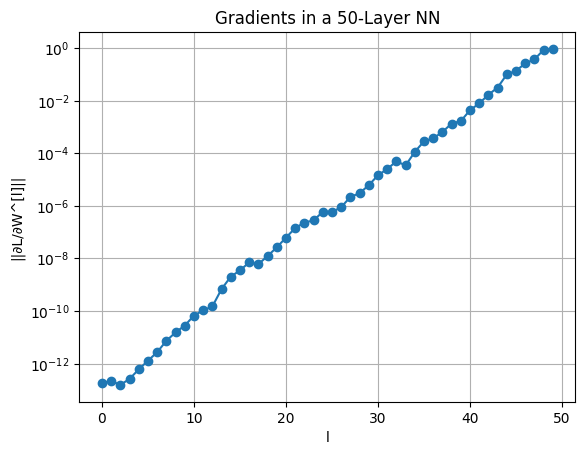

In [7]:
gradient_norms = []
for layer in model.layers:
    norm = layer.weight.grad.norm().item()  # Extract gradient norms for each layer
    gradient_norms.append(norm)

# Plotting the norm of the gradient w.r.t the layers
plt.plot(gradient_norms, marker='o')
plt.title("Gradients in a 50-Layer NN")
plt.xlabel("l")
plt.ylabel(f"||∂L/∂W^[l]||")
plt.yscale("log")
plt.grid(True)
plt.show()

## MNIST Dataset

In [8]:
transform = transforms.Compose([transforms.ToTensor(), 
                            transforms.Normalize((0.5,), (0.5,))])

In [9]:
trainset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainset.data.shape

torch.Size([60000, 28, 28])

In [10]:
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

# Get one batch of images and labels
images, labels = next(iter(trainloader))

In [11]:
# multi-layer perceptron
model = MLP(in_features=784, hidden_features=128, out_features=10,num_layers=50)

# Use CrossEntropyLoss for classification (combines LogSoftmax and NLLLoss)
loss_function = nn.CrossEntropyLoss()

# Forward pass
output = model(images)
loss = loss_function(output, labels)

# Backward pass
loss.backward()

# Extract and plot gradient norms
gradient_norms = []
for layer in model.layers:
    norm = layer.weight.grad.norm().item()
    gradient_norms.append(norm)

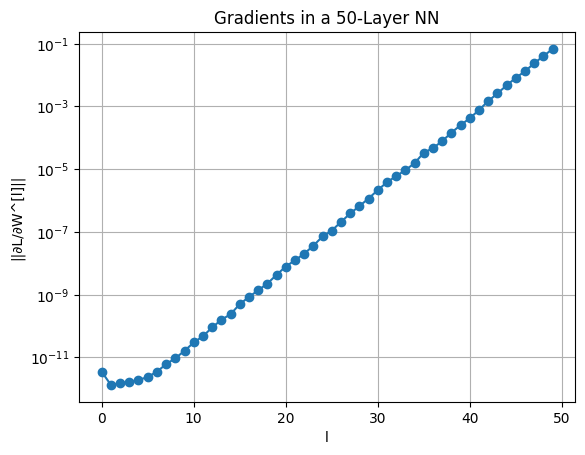

In [12]:
# Plotting the results
plt.plot(gradient_norms, marker='o')
plt.title("Gradients in a 50-Layer NN")
plt.xlabel("l")
plt.ylabel(f"||∂L/∂W^[l]||")
plt.yscale("log")
plt.grid(True)
plt.show()

# ResNet

The ResNet architecture can be described as follows:

$$
\begin{equation}
    \begin{split}
        \boldsymbol{a}^{[0]} &= \boldsymbol{x}\\
        \boldsymbol{a}^{[l+1]} &= \boldsymbol{a}^{[l]}+\boldsymbol{\sigma}\left(W^{[l+1]}\boldsymbol{a}^{[l]} + \boldsymbol{b}^{[l+1]}\right)\,,\quad \quad l=0:L-1
    \end{split}
\end{equation}
$$

where $\boldsymbol{x}\in\mathbb{R}^{n_1}$ is a datapoint, $\boldsymbol{b}^{[l+1]}$ is the bias vector at layer $l$, $W^{[l+1]}$ is the matrix of weights that layer $l+1$ applies to the output of layer $l$ and $L$ is the total number of layers.

**Backpropagation for ResNet:**

The gradient of the loss function w.r.t. $\boldsymbol{b}^{[l]}$ can be calculated as follows:
$$
\begin{align*}
    \frac{\partial \mathcal{L}}{\partial \boldsymbol{b}^{[l]}} = \frac{\partial \mathcal{L}}{\partial\boldsymbol{a}^{[L]}} \cdot \frac{\partial\boldsymbol{a}^{[L]}}{\partial \boldsymbol{a}^{[L-1]}}\dots\frac{\partial \boldsymbol{a}^{[l+1]}}{\partial \boldsymbol{a}^{[l]}}\cdot\frac{\partial \boldsymbol{a}^{[l]}}{\partial \boldsymbol{b}^{[l]}}
\end{align*}
$$

where 
$$
\begin{align*}
    \frac{\partial\boldsymbol{a}^{[l+1]}}{\partial \boldsymbol{a}^{[l]}} = I+\text{diag}(\sigma'(\boldsymbol{z}^{[l+1]})) W^{[l+1]}
\end{align*}
$$

This gives

$$
\begin{align*}
    \frac{\partial \mathcal{L}}{\partial \boldsymbol{b}^{[l]}} = \frac{\partial \mathcal{L}}{\partial\boldsymbol{a}^{[L]}} + \frac{\partial \mathcal{L}}{\partial\boldsymbol{a}^{[L]}}\sum\left(\text{Cross-terms}\right)
\end{align*}
$$

The gradient from the final layer propagates directly to layer $l$ without attenuation. This structural modification guarantees that the core gradient signal remains robust, overcoming the traditional vulnerabilities of deep networks.

In [13]:
# Implementing ResNet
class ResNet(nn.Module):
    def __init__(self, in_features=10, hidden_features=10, out_features=1, num_layers=50):
        super(ResNet, self).__init__()
        
        self.layers = nn.ModuleList()
        
        # Layer 1: Linear
        self.layers.append(nn.Linear(in_features=in_features, out_features=hidden_features))
        
        # Layers 2 to L-1: Linear
        for _ in range(num_layers - 2):
            self.layers.append(nn.Linear(in_features=hidden_features, out_features=hidden_features))
            
        # Layer L: Linear Output
        self.layers.append(nn.Linear(in_features=hidden_features, out_features=out_features))

    def forward(self, x):
        # Flatten the input
        x = x.view(x.size(0), -1)

        x = F.tanh(self.layers[0](x))
        # Layer 1 to L-1: Linear -> Tanh
        for i in range(1,len(self.layers) - 1):
            x = x + F.tanh(self.layers[i](x))              # Adding Skip connections
            
        # Layer L: Output Layer
        x = self.layers[-1](x)
        
        return x

## Random Datapoint

In [14]:
# Multi-layer ResNet model
model = ResNet(in_features=10, hidden_features=10, out_features=1, num_layers=50)

# Forward pass
output = model(x)
loss_function = nn.MSELoss()
loss = loss_function(output, target)

# Backward pass
loss.backward()

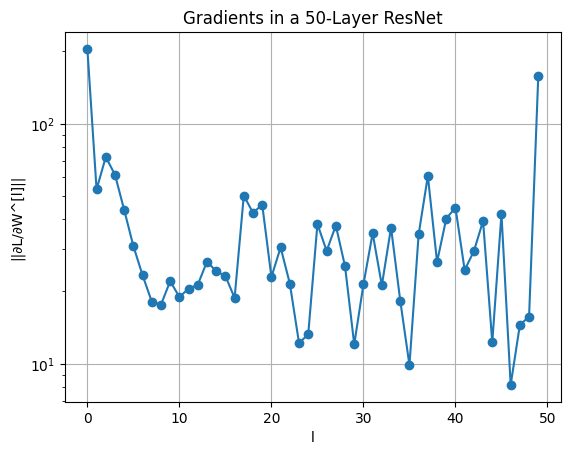

In [15]:
gradient_norms = []
for layer in model.layers:
    norm = layer.weight.grad.norm().item()  # Extract gradient norms for each layer
    gradient_norms.append(norm)

# Plotting the norm of the gradient w.r.t the layers
plt.plot(gradient_norms, marker='o')
plt.title("Gradients in a 50-Layer ResNet")
plt.xlabel("l")
plt.ylabel(f"||∂L/∂W^[l]||")
plt.yscale("log")
plt.grid(True)
plt.show()

## MNIST Dataset

In [16]:
# multi-layer ResNet model
model = ResNet(in_features=784, hidden_features=128, out_features=10,num_layers=50)

# Use CrossEntropyLoss for classification (combines LogSoftmax and NLLLoss)
loss_function = nn.CrossEntropyLoss()

# Forward pass
output = model(images)
loss = loss_function(output, labels)

# Backward pass
loss.backward()


# Extract and plot gradient norms
gradient_norms = []
for layer in model.layers:
    norm = layer.weight.grad.norm().item()
    gradient_norms.append(norm)

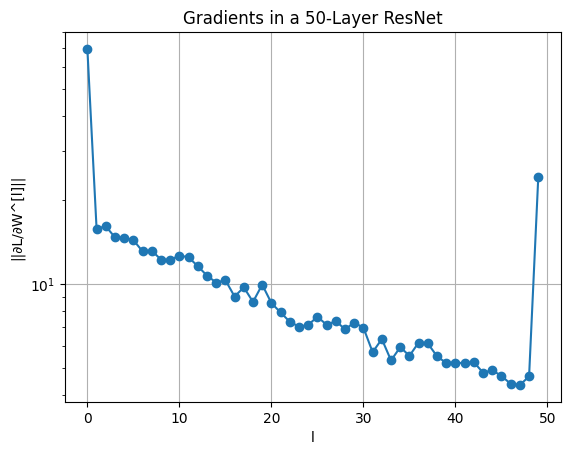

In [17]:
# Plotting the results
plt.plot(gradient_norms, marker='o')
plt.title("Gradients in a 50-Layer ResNet")
plt.xlabel("l")
plt.ylabel(f"||∂L/∂W^[l]||")
plt.yscale("log")
plt.grid(True)
plt.show()

# Comparing Accuracies on MNIST dataset

# Continuous-Time Limit: Neural ODEs

Let $\boldsymbol{\mathcal{F}}(\boldsymbol{a}^{[l]};\boldsymbol{\theta}^{[l]}) = \boldsymbol{\sigma}(W^{[l+1]}\boldsymbol{a}^{[l]} + \boldsymbol{b}^{[l+1]})$ with parameters $\boldsymbol{\theta}^{[l]} = (W^{[l+1]}, \boldsymbol{b}^{[l+1]})$ where $l=0:L-1\,$.

The standard Neural Net consists of learning the map:

$$
\boldsymbol{a}^{[l+1]} = \boldsymbol{\mathcal{F}}(\boldsymbol{a}^{[l]};\boldsymbol{\theta}^{[l]})
$$

whereas ResNet learns the residual between input and output
$$
\boldsymbol{a}^{[l+1]} = \boldsymbol{a}^{[l]} + \boldsymbol{\mathcal{F}}(\boldsymbol{a}^{[l]};\boldsymbol{\theta}^{[l]})
$$

Let us introduce an explicit step size $\Delta l$:

$$
\boldsymbol{a}^{[l+1]} = \boldsymbol{a}^{[l]} + \Delta l\,\boldsymbol{\mathcal{F}}(\boldsymbol{a}^{[l]};\boldsymbol{\theta}^{[l]}).
$$

The standard ResNet is recovered when $\Delta l = 1$. Rearranging the terms, we get

$$
\frac{\boldsymbol{a}^{[l+1]} - \boldsymbol{a}^{[l]}}{\Delta l} = \boldsymbol{\mathcal{F}}(\boldsymbol{a}^{[l]};\boldsymbol{\theta}^{[l]}).
$$

Now, identifying the layer index $l$ with a continuous "depth" variable $t$ and taking the limit $\Delta t \to 0$, the left-hand side becomes a derivative and the discrete state $\boldsymbol{a}^{[l]}$ becomes a continuous trajectory $\boldsymbol{a}(t)$:

$$
\boxed{\ \frac{d\boldsymbol{a}(t)}{dt} = \boldsymbol{\mathcal{F}}(\boldsymbol{a}(t), t;\theta),\qquad \boldsymbol{a}(0) = \boldsymbol{x}.\ }
$$


Starting from the input layer $\boldsymbol{a}(0)$, we can define the output layer $\boldsymbol{a}(T)$ to be the solution to this ODE initial value problem at some time $T$. This value can be computed by a black-box differential equation solver, which evaluates the hidden unit dynamics f wherever necessary to determine the solution with the desired accuracy.

In other words, a deep residual network is a **forward Euler discretization** of an ODE, and the "depth" of the network is the integration interval $[0,T]$. This is the **Neural ODE** viewpoint: instead of stacking a fixed number of layers, we define the dynamics $\boldsymbol{\mathcal{F}}$ and hand the integration to any ODE solver.


The model predicts the state at a target time $T$ by evaluating an Initial Value Problem (IVP) solver:

$$
\begin{align*}
    \boldsymbol{a}(T) &= \boldsymbol{a}(0)+\int_0^T \boldsymbol{\mathcal{F}}(\boldsymbol{a}(t),t;\boldsymbol{\theta})\,dt
\end{align*}
$$


**Training Loop:**

- Forward pass: Provide an initial state $\boldsymbol{a}(0)$ and pass the dynamics $\mathcal{F}$ through an ODE solver which approximates the final output by taking intermediate steps. For example, a Forward-Euler solver taking 4 steps 


When we train with a fixed-step solver, the function the network actually computes is not the true ODE flow, but an approximation of it:

$$
\begin{align*}
    \boldsymbol{a}(T) &\approx \boldsymbol{a}(0)+\sum_k \Delta t\boldsymbol{\mathcal{F}}(\boldsymbol{a}_k)
\end{align*}
$$



For each training pair $(\boldsymbol{x}_i, y_i)$: set $\boldsymbol{a}(0) = \boldsymbol{x}_i$, integrate to get $\boldsymbol{a}(T)$, classify it, and measure the loss against $y_i$. Then adjust $\boldsymbol{\theta}$ (by gradient descent) to minimize that loss over all pairs.
`


where $\Phi$ is the chosen integrator applied $N$ times. So "train with Euler" and "train with RK4" optimize two *different* discrete maps, and the difference between them is the integration error.

To see where this error comes from, Taylor-expand the true solution over one step of size $\Delta t$:

$$
\boldsymbol{a}(t+\Delta t) = \boldsymbol{a}(t) + \Delta t\,\boldsymbol{\mathcal{F}} + \frac{\Delta t^2}{2}\frac{d\boldsymbol{\mathcal{F}}}{dt} + \frac{\Delta t^3}{6}\frac{d^2\boldsymbol{\mathcal{F}}}{dt^2} + \cdots
$$

**Forward Euler** keeps only the first two terms,
$$
\boldsymbol{a}_{k+1} = \boldsymbol{a}_k + \Delta t\,\boldsymbol{\mathcal{F}}(\boldsymbol{a}_k)\,,
$$
discarding everything from $\Delta t^2$ onward, so its local error is $O(\Delta t^2)$ and its global error is $O(\Delta t)$ (first order).

**RK4** evaluates $\boldsymbol{\mathcal{F}}$ at four nested stages,
$$
\begin{aligned}
k_1 &= \boldsymbol{\mathcal{F}}(\boldsymbol{a}_k)\,, &
k_2 &= \boldsymbol{\mathcal{F}}\!\left(\boldsymbol{a}_k + \tfrac{\Delta t}{2}k_1\right)\,, \\
k_3 &= \boldsymbol{\mathcal{F}}\!\left(\boldsymbol{a}_k + \tfrac{\Delta t}{2}k_2\right)\,, &
k_4 &= \boldsymbol{\mathcal{F}}\!\left(\boldsymbol{a}_k + \Delta t\,k_3\right)\,,\\
\end{aligned}
$$
$$
\boldsymbol{a}_{k+1} = \boldsymbol{a}_k + \tfrac{\Delta t}{6}\left(k_1 + 2k_2 + 2k_3 + k_4\right)\,,
$$
which are chosen precisely to reproduce the Taylor series up to $\Delta t^4$. Its local error is $O(\Delta t^5)$ and global error $O(\Delta t^4)$ (fourth order). At the same step count $N$ (same $\Delta t = T/N$), RK4's output is therefore a much more faithful copy of the true $\boldsymbol{a}(T)$ — at the cost of **four** evaluations of $\boldsymbol{\mathcal{F}}$ per step instead of one.

**Why this changes training: the stability function.** Linearize the dynamics near a trajectory, $\partial_{\boldsymbol{a}}\boldsymbol{\mathcal{F}} = J$, so locally $\frac{d\boldsymbol{a}}{dt} = J\boldsymbol{a}$. Every fixed-step method turns one step into multiplication by a matrix $R(\Delta t\,J)$,

$$
\boldsymbol{a}_{k+1} = R(\Delta t\,J)\,\boldsymbol{a}_k\,,
$$

where $R$ is the method's **stability function**, a polynomial approximation of the exact factor $e^{\Delta t J}$:

$$
R_{\text{Euler}}(z) = 1 + z\,,\qquad
R_{\text{RK4}}(z) = 1 + z + \tfrac{z^2}{2!} + \tfrac{z^3}{3!} + \tfrac{z^4}{4!}\,.
$$

This single object controls **both** directions of training:

- **Forward pass:** $\boldsymbol{a}(T) \approx R(\Delta t\,J)^N\,\boldsymbol{a}(0)$.
- **Backward pass (gradients):** backpropagation multiplies the transposes of the per-step Jacobians, i.e. factors of $R(\Delta t\,J)^{\top}$.

The connection to the earlier sections is now exact: for Euler the per-step Jacobian is

$$
\frac{\partial \boldsymbol{a}_{k+1}}{\partial \boldsymbol{a}_k} = I + \Delta t\,J\,,
$$

which is **precisely the ResNet transition Jacobian**. So the vanishing/exploding-gradient behaviour is governed by $|R(\Delta t\,J)|$. If the eigenvalues of $\Delta t\,J$ leave Euler's stability region $\{z : |1+z| \le 1\}$ — a small disk of radius $1$ centred at $-1$ — then $|R| > 1$ and both state and gradients blow up; deep inside, repeated multiplication by a factor $<1$ makes them vanish. RK4's stability region $\{z : |R_{\text{RK4}}(z)| \le 1\}$ is much larger, so for the same $\Delta t$ and the same dynamics it keeps $|R| \approx 1$ over a wider range of eigenvalues — the forward map is more accurate **and** the gradients stay well-scaled.

In summary, Euler and RK4 differ in training because they approximate the flow (forward) and its gradient (backward) to different orders, and because their stability functions admit very different ranges of $\Delta t\,J$ before the gradients distort — *same dynamics $\boldsymbol{\mathcal{F}}$, same $\theta$, same $\Delta t$, but a different discrete map*.

| | Forward Euler | RK4 |
|---|---|---|
| Update | $\boldsymbol{a}_k + \Delta t\,\boldsymbol{\mathcal{F}}$ | $\boldsymbol{a}_k + \tfrac{\Delta t}{6}(k_1 + 2k_2 + 2k_3 + k_4)$ |
| $\boldsymbol{\mathcal{F}}$ evaluations / step | $1$ | $4$ |
| Global error | $O(\Delta t)$ | $O(\Delta t^4)$ |
| Stability function $R(z)$ | $1 + z$ | $\sum_{j=0}^{4} z^j/j!$ |
| Per-step Jacobian | $I + \Delta t\,J$ (the ResNet block) | higher-order polynomial in $\Delta t\,J$ |
| Effect on training | crude flow; gradients distort unless $\Delta t$ is small | accurate flow; gradients well-scaled over a wider range of $\Delta t\,J$ |

The punchline: the integrator's stability function $R(\Delta t\,J)$ is what propagates both the state and the gradient. Euler's $R = 1 + z$ is exactly the ResNet Jacobian, and RK4 replaces it with a higher-order, larger-stability-region approximation of $e^{\Delta t J}$.

## Training a Neural ODE (2D demonstration)

To see a Neural ODE actually learn, we train one on a 2D "two-moons" classification problem. The input point is the initial condition $\boldsymbol{a}(0) = \boldsymbol{x}$; we integrate the learned dynamics $\boldsymbol{\mathcal{F}}$ to time $T$, and a linear layer classifies the final state $\boldsymbol{a}(T)$. We integrate with a fixed-step solver and compare **forward Euler** against **RK4** at the same step budget to see the effect of integrator accuracy. Gradients are obtained by ordinary autograd through the solver (no adjoint, no external ODE library).

We use two moons rather than concentric circles on purpose: the flow of an ODE is a homeomorphism (trajectories cannot cross), so a plain 2D Neural ODE cannot separate topologically *nested* classes such as concentric circles without adding extra dimensions. The two moons are not nested, so a 2D flow can disentangle them.

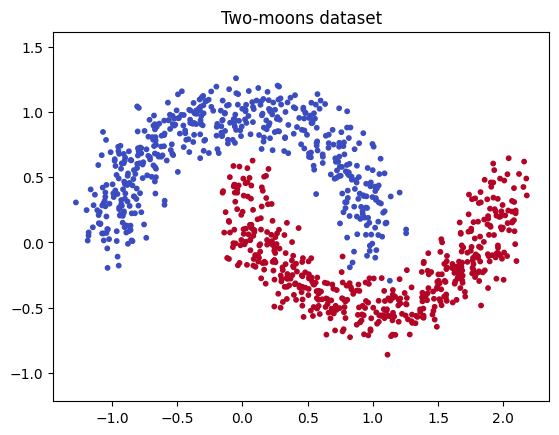

In [18]:
import numpy as np

def make_moons(n=1000, noise=0.12, seed=0):
    rng = np.random.default_rng(seed)
    n_a = n // 2
    n_b = n - n_a
    t_a = np.pi * rng.random(n_a)
    t_b = np.pi * rng.random(n_b)
    outer = np.c_[np.cos(t_a),     np.sin(t_a)]
    inner = np.c_[1 - np.cos(t_b), 0.5 - np.sin(t_b)]
    X = np.vstack([outer, inner]) + noise * rng.standard_normal((n, 2))
    y = np.array([0] * n_a + [1] * n_b)
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

X, y = make_moons()
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=10)
plt.title("Two-moons dataset")
plt.axis("equal")
plt.show()

In [19]:
def integrate(func, a, T=1.0, N=10, method="rk4"):
    """Fixed-step integration of da/dt = func(a) on [0, T] with N steps."""
    dt = T / N
    for _ in range(N):
        if method == "euler":
            a = a + dt * func(a)
        elif method == "rk4":
            k1 = func(a)
            k2 = func(a + 0.5 * dt * k1)
            k3 = func(a + 0.5 * dt * k2)
            k4 = func(a + dt * k3)
            a = a + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)
        else:
            raise ValueError(method)
    return a

class NeuralODE(nn.Module):
    def __init__(self, dim=2, hidden=64, T=1.0, N=10, method="rk4"):
        super().__init__()
        # The dynamics F(a); autonomous (no explicit t-dependence) for simplicity
        self.func = nn.Sequential(
            nn.Linear(dim, hidden), nn.Tanh(), nn.Linear(hidden, dim)
        )
        self.classifier = nn.Linear(dim, 2)
        self.T, self.N, self.method = T, N, method

    def forward(self, x):
        aT = integrate(self.func, x, self.T, self.N, self.method)
        return self.classifier(aT)

In [20]:
def train(model, X, y, epochs=400, lr=1e-2):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    for _ in range(epochs):
        opt.zero_grad()
        loss = criterion(model(X), y)
        loss.backward()
        opt.step()
    with torch.no_grad():
        acc = (model(X).argmax(1) == y).float().mean().item()
    return acc

Accuracy with 5 steps  |  Euler: 0.997   RK4: 0.997


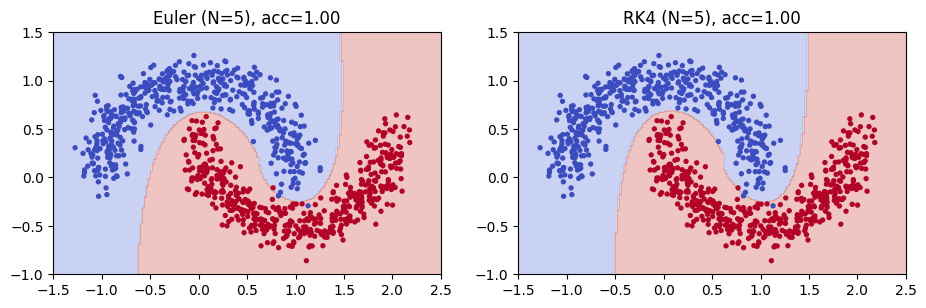

In [21]:
N_STEPS = 5  # deliberately small to expose integrator accuracy differences

torch.manual_seed(0)
ode_euler = NeuralODE(N=N_STEPS, method="euler")
acc_euler = train(ode_euler, X, y)

torch.manual_seed(0)
ode_rk4 = NeuralODE(N=N_STEPS, method="rk4")
acc_rk4 = train(ode_rk4, X, y)

print(f"Accuracy with {N_STEPS} steps  |  Euler: {acc_euler:.3f}   RK4: {acc_rk4:.3f}")

def plot_boundary(model, ax, title):
    xx, yy = np.meshgrid(np.linspace(-1.5, 2.5, 200), np.linspace(-1.0, 1.5, 200))
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    with torch.no_grad():
        zz = model(grid).argmax(1).numpy().reshape(xx.shape)
    ax.contourf(xx, yy, zz, cmap="coolwarm", alpha=0.3)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=8)
    ax.set_title(title)
    ax.set_aspect("equal")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_boundary(ode_euler, axes[0], f"Euler (N={N_STEPS}), acc={acc_euler:.2f}")
plot_boundary(ode_rk4,   axes[1], f"RK4 (N={N_STEPS}), acc={acc_rk4:.2f}")
plt.show()

We learn the parameters $\theta$ of a single shared dynamics $\boldsymbol{\mathcal{F}}$ such that, starting each input as an initial condition and integrating the ODE to time $T$, the output $\boldsymbol{a}(T)$ minimizes the loss; at test time we integrate that same ODE from the new input.